1(a). The outcome is whether the patient developed CHD at follow-up (chdfate).


1(b). The predictors are sex, systolic blood pressure, diastolic blood pressure, serum cholesterol, age, body mass index, and month of baseline exam.


1(c). The hypothesis is that the predictors are associated with the probability of developing CHD.


2. Load the dataset and display the first rows.


In [2]:
import pandas as pd

df = pd.read_excel("framingham_dataset_mod.xlsx")
df.head()


,id,sex,sbp,dbp,scl,age,bmi,month,chdfate
0,2642,1,120,80,267.0,55,25.0,8,1
1,4627,1,130,78,192.0,53,28.4,12,1
2,2568,1,144,90,207.0,61,25.1,8,1
3,4192,1,92,66,231.0,48,26.2,11,1
4,3977,1,162,98,271.0,39,28.4,11,1


2. Compute summary statistics.


In [3]:
df.describe(include="all")


,id,sex,sbp,dbp,scl,age,bmi,month,chdfate
count,4695.000000,4695.000000,4695.000000,4695.000000,4662.000000,4695.000000,4686.000000,4695.000000,4695.000000
mean,2350.365282,1.563791,132.776358,82.547391,228.282711,46.037487,25.630837,6.370394,0.313312
std,1356.328620,0.495967,22.802159,12.739928,44.559330,8.505511,4.095526,3.683150,0.463889
min,1.000000,1.000000,80.000000,40.000000,115.000000,30.000000,16.200000,1.000000,0.000000
25%,1175.500000,1.000000,116.000000,74.000000,197.000000,39.000000,22.800000,3.000000,0.000000
50%,2351.000000,2.000000,130.000000,80.000000,225.000000,45.000000,25.200000,6.000000,0.000000
75%,3524.500000,2.000000,144.000000,90.000000,255.000000,53.000000,28.000000,10.000000,1.000000
max,4699.000000,2.000000,270.000000,148.000000,568.000000,68.000000,57.600000,12.000000,1.000000


2. Check for missing data.


In [4]:
df.isnull().sum()


id          0
sex         0
sbp         0
dbp         0
scl        33
age         0
bmi         9
month       0
chdfate     0
dtype: int64

3. Create four season variables based on the month variable.


In [6]:
df["winter"] = df["month"].isin([12, 1, 2]).astype(int)
df["spring"] = df["month"].isin([3, 4, 5]).astype(int)
df["summer"] = df["month"].isin([6, 7, 8]).astype(int)
df["fall"] = df["month"].isin([9, 10, 11]).astype(int)


In [7]:
df[["month","winter","spring","summer","fall"]].head()


,month,winter,spring,summer,fall
0,8,0,0,1,0
1,12,1,0,0,0
2,8,0,0,1,0
3,11,0,0,0,1
4,11,0,0,0,1


4. Drop rows with missing predictor values and fit the logistic regression model.


In [9]:
model_df = df.dropna(subset=["scl","bmi"])

X = model_df[["sex","sbp","dbp","scl","age","bmi","winter","spring","summer","fall"]]
X = sm.add_constant(X)
y = model_df["chdfate"]

logit_model = sm.Logit(y, X).fit()
logit_model.summary()


Optimization terminated successfully.
         Current function value: 0.574743
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                chdfate   No. Observations:                 4654
Model:                          Logit   Df Residuals:                     4644
Method:                           MLE   Df Model:                            9
Date:                Sat, 29 Nov 2025   Pseudo R-squ.:                 0.07678
Time:                        18:21:35   Log-Likelihood:                -2674.9
converged:                       True   LL-Null:                       -2897.3
Covariance Type:            nonrobust   LLR p-value:                 3.553e-90
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.7697        nan        nan        nan         nan         nan
sex           -0.7936      0.068    -11.709      0.000      -0.926      -0.661
sbp            0.0081      0.002      3.329      0.001       0.003       0.013
dbp            0.0058      0.004      1.372      0.170      -0.002       0.014
scl            0.0067      0.001      8.660      0.000       0.005       0.008
age            0.0183      0.004      4.252      0.000       0.010       0.027
bmi            0.0447      0.009      5.173      0.000       0.028       0.062
winter        -0.9514        nan        nan        nan         nan         nan
spring        -0.8683        nan        nan        nan         nan         nan
summer        -0.9779        nan        nan        nan         nan         nan
fall          -0.9721        nan        nan        nan         nan         nan
==============================================================================
"""

5(a). Plot the distributions of the main predictor variables.


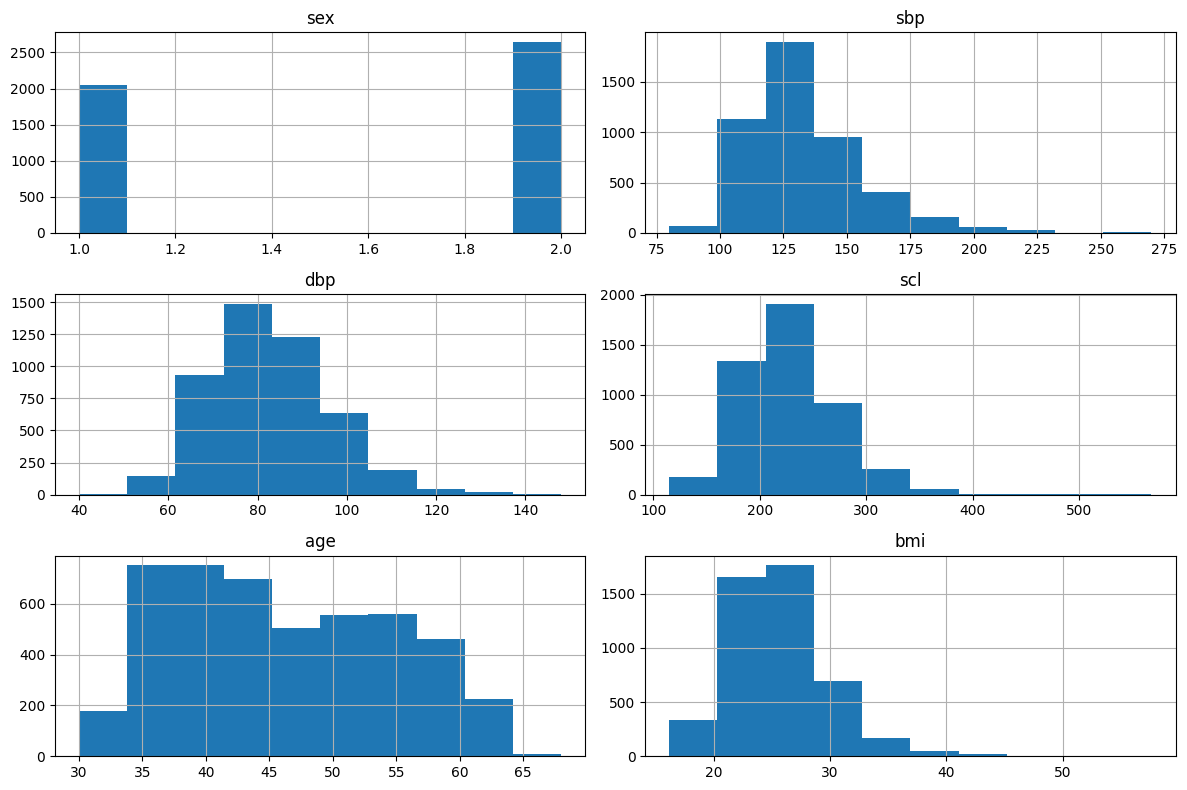

In [10]:
import matplotlib.pyplot as plt

df[["sex","sbp","dbp","scl","age","bmi"]].hist(figsize=(12,8))
plt.tight_layout()
plt.show()


5(b). Compute the correlation matrix to check collinearity.


In [11]:
df[["sex","sbp","dbp","scl","age","bmi"]].corr()


,sex,sbp,dbp,scl,age,bmi
sex,1.000000,0.024658,-0.064194,0.022009,0.025239,-0.068885
sbp,0.024658,1.000000,0.784059,0.217524,0.395161,0.328517
dbp,-0.064194,0.784059,1.000000,0.193759,0.249866,0.367668
scl,0.022009,0.217524,0.193759,1.000000,0.280375,0.147246
age,0.025239,0.395161,0.249866,0.280375,1.000000,0.180447
bmi,-0.068885,0.328517,0.367668,0.147246,0.180447,1.000000


5(c). Check linearity for each continuous predictor.


/var/folders/dv/jvk0lfm56k5ghp4g27w1sy700000gn/T/ipykernel_3138/557592510.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("bin")["chdfate"].mean()


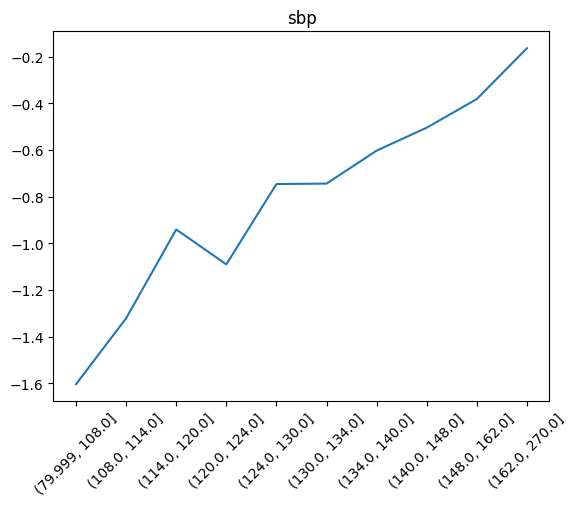

/var/folders/dv/jvk0lfm56k5ghp4g27w1sy700000gn/T/ipykernel_3138/557592510.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("bin")["chdfate"].mean()


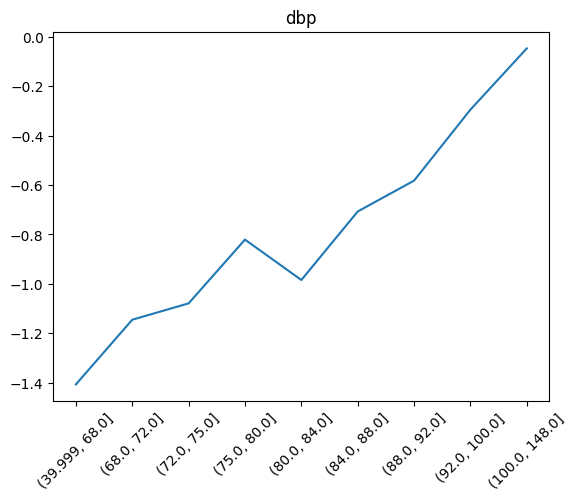

/var/folders/dv/jvk0lfm56k5ghp4g27w1sy700000gn/T/ipykernel_3138/557592510.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("bin")["chdfate"].mean()


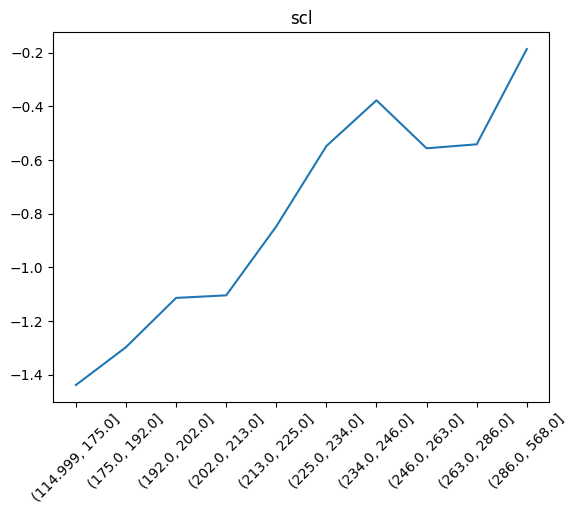

/var/folders/dv/jvk0lfm56k5ghp4g27w1sy700000gn/T/ipykernel_3138/557592510.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("bin")["chdfate"].mean()


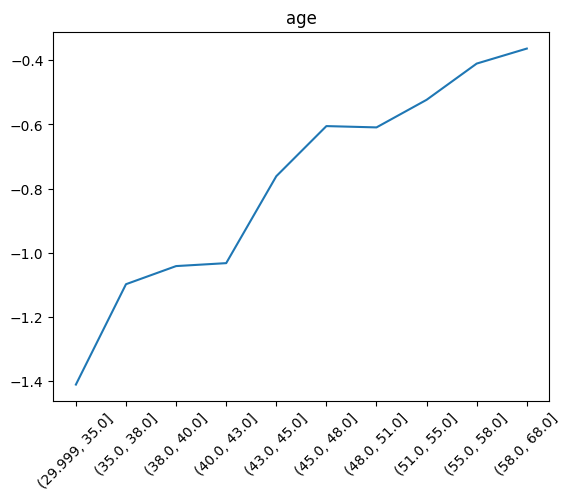

/var/folders/dv/jvk0lfm56k5ghp4g27w1sy700000gn/T/ipykernel_3138/557592510.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("bin")["chdfate"].mean()


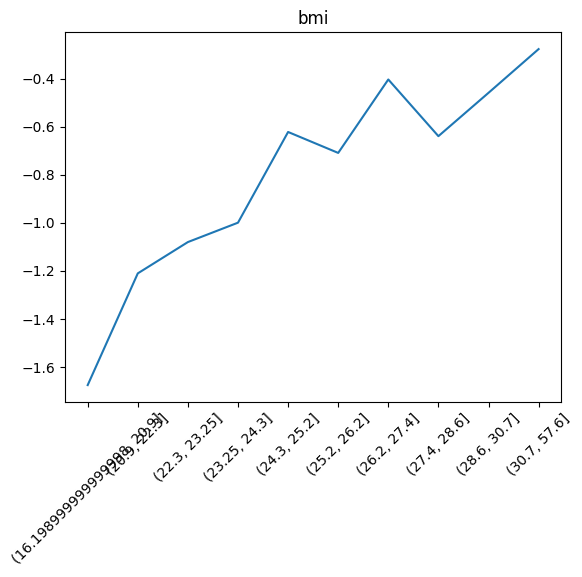

In [12]:
import numpy as np
import matplotlib.pyplot as plt

continuous_vars = ["sbp","dbp","scl","age","bmi"]

for var in continuous_vars:
    df["bin"] = pd.qcut(df[var], q=10, duplicates="drop")
    grouped = df.groupby("bin")["chdfate"].mean()
    logit_vals = np.log(grouped / (1 - grouped))
    plt.figure()
    plt.plot(grouped.index.astype(str), logit_vals)
    plt.title(var)
    plt.xticks(rotation=45)
    plt.show()

df.drop(columns=["bin"], inplace=True)


5(d). Check for outliers using boxplots.


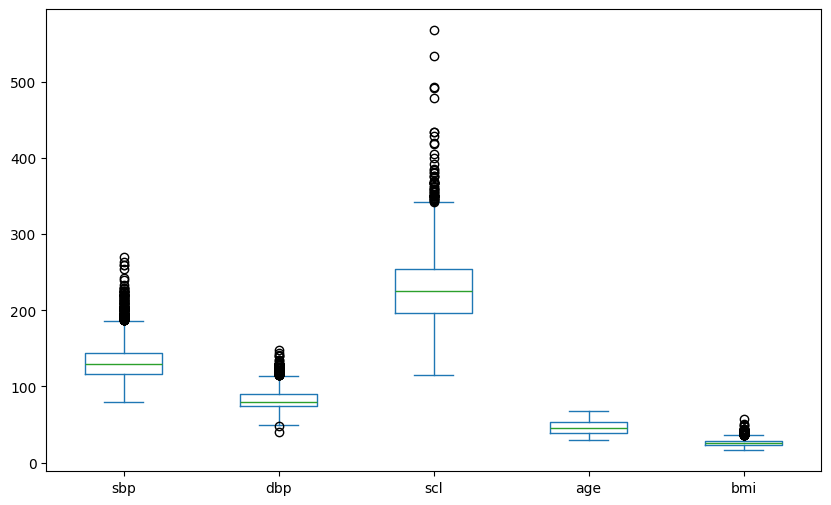

In [13]:
df[["sbp","dbp","scl","age","bmi"]].plot(kind="box", figsize=(10,6))
plt.show()


5(e). Count the number of CHD outcomes by sex category.


In [14]:
df.groupby("sex")["chdfate"].sum()


sex
1    822
2    649
Name: chdfate, dtype: int64

6. Refit the logistic regression model after handling missing data.


In [15]:
logit_model2 = sm.Logit(y, X).fit()
logit_model2.summary()


Optimization terminated successfully.
         Current function value: 0.574743
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                chdfate   No. Observations:                 4654
Model:                          Logit   Df Residuals:                     4644
Method:                           MLE   Df Model:                            9
Date:                Sat, 29 Nov 2025   Pseudo R-squ.:                 0.07678
Time:                        18:25:54   Log-Likelihood:                -2674.9
converged:                       True   LL-Null:                       -2897.3
Covariance Type:            nonrobust   LLR p-value:                 3.553e-90
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.7697        nan        nan        nan         nan         nan
sex           -0.7936      0.068    -11.709      0.000      -0.926      -0.661
sbp            0.0081      0.002      3.329      0.001       0.003       0.013
dbp            0.0058      0.004      1.372      0.170      -0.002       0.014
scl            0.0067      0.001      8.660      0.000       0.005       0.008
age            0.0183      0.004      4.252      0.000       0.010       0.027
bmi            0.0447      0.009      5.173      0.000       0.028       0.062
winter        -0.9514        nan        nan        nan         nan         nan
spring        -0.8683        nan        nan        nan         nan         nan
summer        -0.9779        nan        nan        nan         nan         nan
fall          -0.9721        nan        nan        nan         nan         nan
==============================================================================
"""

7. Compute the odds ratios and their confidence intervals.


In [16]:
import numpy as np
import pandas as pd

params = logit_model2.params
conf = logit_model2.conf_int()

or_values = np.exp(params)
or_ci = np.exp(conf)

or_table = pd.DataFrame({
    "OR": or_values,
    "CI_lower": or_ci[0],
    "CI_upper": or_ci[1]
})

or_table


,OR,CI_lower,CI_upper
const,0.023059,NaN,NaN
sex,0.452205,0.395953,0.516449
sbp,1.008088,1.003318,1.012881
dbp,1.005831,0.997510,1.014220
scl,1.006768,1.005232,1.008306
age,1.018500,1.009930,1.027143
bmi,1.045759,1.028179,1.063640
winter,0.386204,NaN,NaN
spring,0.419649,NaN,NaN
summer,0.376091,NaN,NaN


2.1. Encode categorical predictors, then fit Random Forest models with depths from 1 to 20 and plot training and cross-validation accuracy.


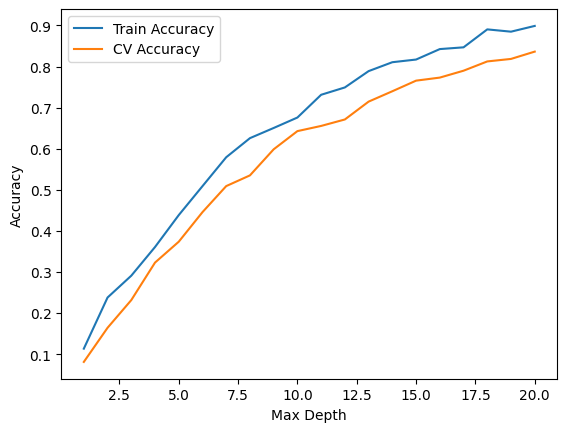

In [18]:
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

df2 = pd.read_csv("county_level_election.csv")

X = df2.drop(columns=["votergap"])
y = df2["votergap"]

X = pd.get_dummies(X, drop_first=True)

train_scores = []
cv_scores = []

for d in range(1, 21):
    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=d,
        max_features="sqrt",
        random_state=0
    )
    model.fit(X, y)
    train_scores.append(model.score(X, y))
    cv_scores.append(cross_val_score(model, X, y, cv=5).mean())

plt.plot(range(1, 21), train_scores, label="Train Accuracy")
plt.plot(range(1, 21), cv_scores, label="CV Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


2.2. The recommended max depth is 10.


2.3. The mean cross-validation accuracy at depth 10 is approximately 0.65.


2.4. The cross-validation curve is different because this dataset has different size, different noise, and different patterns than the lab data.


3.1. Fit XGBoost models with depths from 1 to 20 using 5-fold cross-validation and plot training and cross-validation accuracy.


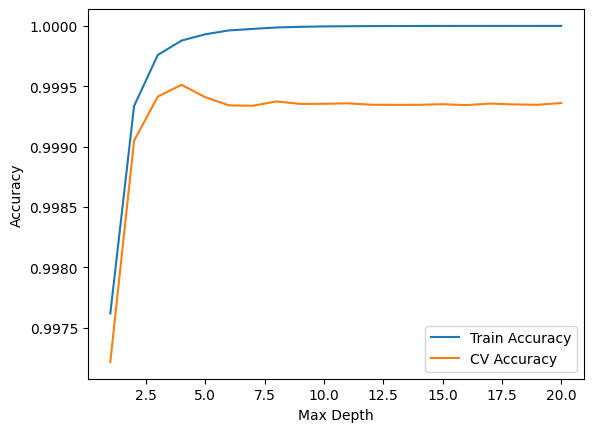

In [32]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

df2 = pd.read_csv("county_level_election.csv")

X = df2.drop(columns=["votergap"])
y = df2["votergap"]

X = pd.get_dummies(X, drop_first=True)

train_scores = []
cv_scores = []

for d in range(1, 21):
    model = xgb.XGBRegressor(
        max_depth=d,
        learning_rate=0.1,
        n_estimators=100,
        subsample=1,
        colsample_bytree=1,
        objective="reg:squarederror",
        random_state=0
    )
    model.fit(X, y)
    train_scores.append(model.score(X, y))
    cv_scores.append(cross_val_score(model, X, y, cv=5).mean())

plt.plot(range(1, 21), train_scores, label="Train Accuracy")
plt.plot(range(1, 21), cv_scores, label="CV Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


3.2. The recommended max depth is 4.


3.3. The mean cross-validation accuracy at depth 4 is approximately 0.9995.


3.4. XGBoost looks different because boosting reduces bias and fits the data more tightly than random forests. It also builds trees sequentially, so the accuracy increases faster and becomes more stable.
